
# BSD10K Binary Confidence MLP + Model Analysis Notebook

이 노트북은 Colab에서 바로 실행할 수 있도록 만든 버전입니다.

## 목표

```text
confidence 1,2,3 -> 0
confidence 4,5   -> 1
```

즉, BSD10K sample이 high-confidence sample인지 예측하는 binary classification 실험입니다.

## 포함된 분석

- Google Drive 경로 검증
- Drive `.npy` → Colab `/content` 로컬 복사
- metadata / confidence / class 분포 분석
- audio/text/class feature 생성
- MLP binary classification 실험
- summary table
- loss / metric graph
- confusion matrix
- classification report
- PR curve / ROC curve
- threshold sweep
- threshold별 precision / recall / F1 / retained ratio 분석
- class별 error 분석
- prediction probability 분포 분석
- 결과 CSV 저장


In [1]:

# =====================================================
# 1. SETTINGS
# =====================================================

import os
import glob
import shutil
import random
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    average_precision_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("Notebook initialized.")


DEVICE: cpu
Notebook initialized.


In [2]:

# =====================================================
# 2. GOOGLE DRIVE MOUNT
# =====================================================

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

# =====================================================
# 3. PATH SETTINGS
# =====================================================

# 사용자가 제공한 실제 Drive 경로

METADATA_CSV = "/content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv"

DRIVE_AUDIO_EMB_DIR = "/content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings"
DRIVE_TEXT_EMB_DIR  = "/content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings"

# Colab local path
# 주의: 학습에서는 Drive를 직접 읽지 않고, /content 로컬 복사본만 읽는다.

LOCAL_BASE_DIR = "/content/bsd10k_features"

AUDIO_EMB_DIR = os.path.join(
    LOCAL_BASE_DIR,
    "clap_audio_embeddings"
)

TEXT_EMB_DIR = os.path.join(
    LOCAL_BASE_DIR,
    "clap_text_embeddings"
)

# metadata column names

SOUND_ID_COL = "sound_id"
CLASS_COL = "class"
CONFIDENCE_COL = "confidence"

# class_top 컬럼이 있으면 자동으로 사용하고, 없으면 class 문자열 앞부분으로 추정한다.
CLASS_TOP_COL = "class_top"

print("METADATA_CSV:", METADATA_CSV)
print("DRIVE_AUDIO_EMB_DIR:", DRIVE_AUDIO_EMB_DIR)
print("DRIVE_TEXT_EMB_DIR:", DRIVE_TEXT_EMB_DIR)
print("LOCAL AUDIO_EMB_DIR:", AUDIO_EMB_DIR)
print("LOCAL TEXT_EMB_DIR:", TEXT_EMB_DIR)


METADATA_CSV: /content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv
DRIVE_AUDIO_EMB_DIR: /content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings
DRIVE_TEXT_EMB_DIR: /content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings
LOCAL AUDIO_EMB_DIR: /content/bsd10k_features/clap_audio_embeddings
LOCAL TEXT_EMB_DIR: /content/bsd10k_features/clap_text_embeddings


In [4]:

# =====================================================
# 4. PATH VALIDATION
# =====================================================

assert os.path.exists(METADATA_CSV), f"metadata csv not found: {METADATA_CSV}"
assert os.path.exists(DRIVE_AUDIO_EMB_DIR), f"audio embedding dir not found: {DRIVE_AUDIO_EMB_DIR}"
assert os.path.exists(DRIVE_TEXT_EMB_DIR), f"text embedding dir not found: {DRIVE_TEXT_EMB_DIR}"

print("metadata exists:", os.path.exists(METADATA_CSV))
print("audio dir exists:", os.path.exists(DRIVE_AUDIO_EMB_DIR))
print("text dir exists:", os.path.exists(DRIVE_TEXT_EMB_DIR))

print("audio npy count:", len(glob.glob(DRIVE_AUDIO_EMB_DIR + "/*.npy")))
print("text npy count:", len(glob.glob(DRIVE_TEXT_EMB_DIR + "/*.npy")))


metadata exists: True
audio dir exists: True
text dir exists: True
audio npy count: 10956
text npy count: 10972


In [5]:

# =====================================================
# 5. DRIVE -> LOCAL COPY
# =====================================================

# Drive에서 np.load를 반복하면 매우 느리므로, 반드시 /content로 복사 후 로딩한다.

if os.path.exists(LOCAL_BASE_DIR):
    shutil.rmtree(LOCAL_BASE_DIR)

os.makedirs(LOCAL_BASE_DIR, exist_ok=True)

print("Copying audio embeddings from Drive to /content ...")
shutil.copytree(DRIVE_AUDIO_EMB_DIR, AUDIO_EMB_DIR)

print("Copying text embeddings from Drive to /content ...")
shutil.copytree(DRIVE_TEXT_EMB_DIR, TEXT_EMB_DIR)

print("Local copy complete.")

print("local audio npy count:", len(glob.glob(AUDIO_EMB_DIR + "/*.npy")))
print("local text npy count:", len(glob.glob(TEXT_EMB_DIR + "/*.npy")))


Copying audio embeddings from Drive to /content ...
Copying text embeddings from Drive to /content ...
Local copy complete.
local audio npy count: 10956
local text npy count: 10972


In [6]:

# =====================================================
# 6. LOAD METADATA
# =====================================================

df = pd.read_csv(METADATA_CSV)

print("metadata shape:", df.shape)
display(df.head())

print("columns:", list(df.columns))

assert SOUND_ID_COL in df.columns, f"{SOUND_ID_COL} column not found"
assert CLASS_COL in df.columns, f"{CLASS_COL} column not found"
assert CONFIDENCE_COL in df.columns, f"{CONFIDENCE_COL} column not found"

df[SOUND_ID_COL] = df[SOUND_ID_COL].astype(str).str.strip()
df[CLASS_COL] = df[CLASS_COL].astype(str).str.strip()

print()
print("confidence value counts:")
display(df[CONFIDENCE_COL].value_counts(dropna=False).sort_index())

print()
print("class value counts top 20:")
display(df[CLASS_COL].value_counts().head(20))


metadata shape: (10956, 10)


,sound_id,class,class_idx,class_top,confidence,uploader,license,title,tags,description
0,185755,fx-o,401,fx,4,marcgp13,http://creativecommons.org/licenses/by/3.0/,microwave_oven.wav,"campus-upf,UPF-CS13,microwave,heat,bell,noise","A microwave oven operating, including the soun..."
1,358405,is-w,203,is,5,MTG,http://creativecommons.org/licenses/by/3.0/,Sax Alto - F5,"good-sounds,single-note,multisample,sax,neuman...",Recorded in the context of the good-sounds.org...
2,358760,is-w,203,is,4,MTG,http://creativecommons.org/licenses/by/3.0/,Sax Alto - G# Major,"good-sounds,sax,neumann-U87,GsharpMajor,scale,...",Recorded in the context of the good-sounds.org...
3,432206,fx-o,401,fx,4,curesforbrokenhearts,http://creativecommons.org/publicdomain/zero/1.0/,EGG SHAKER,"egg-shaker,shaker,percussion",Large plastic egg shaker
4,80630,sp-s,301,sp,5,tim.kahn,https://creativecommons.org/licenses/by/4.0/,mechanics.wav,"american,english,female,fight,speak,talk,text,...","A request for the user ""asexton"", my girlfrien..."


columns: ['sound_id', 'class', 'class_idx', 'class_top', 'confidence', 'uploader', 'license', 'title', 'tags', 'description']

confidence value counts:


,count
confidence,
1,107
2,748
3,3281
4,6043
5,777



class value counts top 20:


,count
class,
fx-o,1211
fx-h,975
sp-s,806
m-si,721
ss-u,719
m-sp,683
fx-n,652
is-p,606
is-w,566


Binary target distribution:


,count
binary_target,
0,4136
1,6820



Binary target ratio:


,proportion
binary_target,
0,0.37751
1,0.62249



Confidence by class top 20:


confidence_int,1,2,3,4,5
class,,,,,
fx-a,0.012,0.078,0.349,0.470,0.090
fx-el,0.010,0.053,0.284,0.625,0.029
fx-ex,0.020,0.125,0.552,0.296,0.007
fx-h,0.011,0.059,0.286,0.635,0.008
fx-m,0.011,0.054,0.344,0.570,0.022
fx-n,0.003,0.029,0.275,0.678,0.015
fx-o,0.005,0.041,0.297,0.650,0.007
fx-v,0.015,0.045,0.328,0.597,0.015
is-e,0.007,0.077,0.458,0.431,0.027


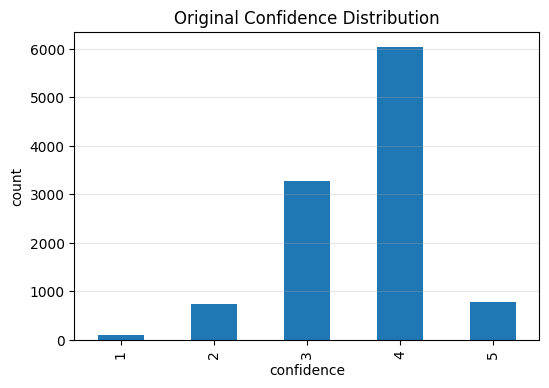

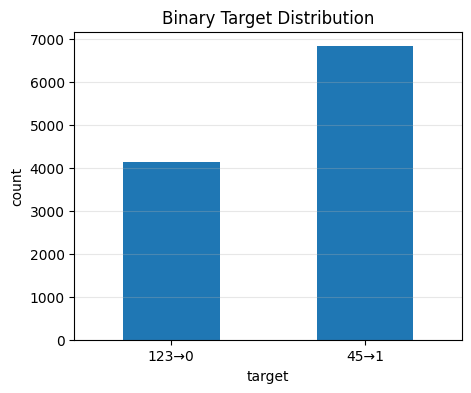

In [7]:

# =====================================================
# 7. BASIC DATA ANALYSIS
# =====================================================

analysis_df = df.copy()

analysis_df["confidence_int"] = pd.to_numeric(
    analysis_df[CONFIDENCE_COL],
    errors="coerce"
)

analysis_df["binary_target"] = analysis_df["confidence_int"].map(
    lambda x: 0 if x in [1, 2, 3] else (1 if x in [4, 5] else np.nan)
)

print("Binary target distribution:")
display(analysis_df["binary_target"].value_counts(dropna=False).sort_index())

print()
print("Binary target ratio:")
display(analysis_df["binary_target"].value_counts(normalize=True, dropna=False).sort_index())

print()
print("Confidence by class top 20:")
display(
    pd.crosstab(
        analysis_df[CLASS_COL],
        analysis_df["confidence_int"],
        normalize="index"
    ).round(3).head(20)
)

plt.figure(figsize=(6, 4))
analysis_df["confidence_int"].value_counts().sort_index().plot(kind="bar")
plt.title("Original Confidence Distribution")
plt.xlabel("confidence")
plt.ylabel("count")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(5, 4))
analysis_df["binary_target"].value_counts().sort_index().plot(kind="bar")
plt.title("Binary Target Distribution")
plt.xlabel("target")
plt.ylabel("count")
plt.xticks([0, 1], ["123→0", "45→1"], rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


In [8]:

# =====================================================
# 8. CLASS LABEL ENCODING
# =====================================================

unique_classes = sorted(df[CLASS_COL].dropna().unique().tolist())

class_to_idx = {
    cls_name: idx
    for idx, cls_name in enumerate(unique_classes)
}

idx_to_class = {
    idx: cls_name
    for cls_name, idx in class_to_idx.items()
}

NUM_CLASSES = len(class_to_idx)

print("NUM_CLASSES:", NUM_CLASSES)
print("sample class mapping:")
for k, v in list(class_to_idx.items())[:20]:
    print(k, "->", v)

assert NUM_CLASSES > 0, "No classes found."

# class_top 생성
if CLASS_TOP_COL in df.columns:
    df[CLASS_TOP_COL] = df[CLASS_TOP_COL].astype(str).str.strip()
else:
    # 예: fx-o -> fx, is-w -> is
    df[CLASS_TOP_COL] = df[CLASS_COL].astype(str).str.split("-").str[0]

unique_top_classes = sorted(df[CLASS_TOP_COL].dropna().unique().tolist())

class_top_to_idx = {
    cls_name: idx
    for idx, cls_name in enumerate(unique_top_classes)
}

NUM_TOP_CLASSES = len(class_top_to_idx)

print()
print("NUM_TOP_CLASSES:", NUM_TOP_CLASSES)
print("sample top-class mapping:")
for k, v in list(class_top_to_idx.items())[:20]:
    print(k, "->", v)


NUM_CLASSES: 23
sample class mapping:
fx-a -> 0
fx-el -> 1
fx-ex -> 2
fx-h -> 3
fx-m -> 4
fx-n -> 5
fx-o -> 6
fx-v -> 7
is-e -> 8
is-k -> 9
is-p -> 10
is-s -> 11
is-w -> 12
m-m -> 13
m-si -> 14
m-sp -> 15
sp-c -> 16
sp-p -> 17
sp-s -> 18
ss-i -> 19

NUM_TOP_CLASSES: 5
sample top-class mapping:
fx -> 0
is -> 1
m -> 2
sp -> 3
ss -> 4


In [9]:

# =====================================================
# 9. LOAD EMBEDDINGS WITH TQDM
# =====================================================

def normalize_sound_id(x):
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s


def confidence_to_binary_label(confidence):
    confidence = int(confidence)

    if confidence in [1, 2, 3]:
        return 0

    if confidence in [4, 5]:
        return 1

    return None


rows = []

missing_audio = 0
missing_text = 0
invalid_confidence = 0
load_error = 0

for _, row in tqdm(df.iterrows(), total=len(df)):

    sound_id = normalize_sound_id(row[SOUND_ID_COL])

    audio_path = os.path.join(AUDIO_EMB_DIR, f"{sound_id}.npy")
    text_path = os.path.join(TEXT_EMB_DIR, f"{sound_id}.npy")

    if not os.path.exists(audio_path):
        missing_audio += 1
        continue

    if not os.path.exists(text_path):
        missing_text += 1
        continue

    try:
        audio_vec = np.load(audio_path)
        text_vec = np.load(text_path)
    except Exception:
        load_error += 1
        continue

    class_name = str(row[CLASS_COL]).strip()
    class_id = class_to_idx[class_name]

    class_top_name = str(row[CLASS_TOP_COL]).strip()
    class_top_id = class_top_to_idx[class_top_name]

    binary_label = confidence_to_binary_label(row[CONFIDENCE_COL])

    if binary_label is None:
        invalid_confidence += 1
        continue

    rows.append({
        "sound_id": sound_id,
        "audio_emb": audio_vec,
        "text_emb": text_vec,
        "class_name": class_name,
        "class_id": class_id,
        "class_top_name": class_top_name,
        "class_top_id": class_top_id,
        "binary_label": binary_label,
        "original_confidence": int(row[CONFIDENCE_COL])
    })


print("총 metadata rows:", len(df))
print("사용 가능 rows:", len(rows))
print("missing audio:", missing_audio)
print("missing text:", missing_text)
print("invalid confidence:", invalid_confidence)
print("load error:", load_error)

assert len(rows) > 0, "No usable rows. Check paths, sound_id matching, or confidence values."

print("audio_emb shape:", rows[0]["audio_emb"].shape)
print("text_emb shape:", rows[0]["text_emb"].shape)
print("first row:", {
    "sound_id": rows[0]["sound_id"],
    "class_name": rows[0]["class_name"],
    "class_id": rows[0]["class_id"],
    "class_top_name": rows[0]["class_top_name"],
    "class_top_id": rows[0]["class_top_id"],
    "binary_label": rows[0]["binary_label"],
    "original_confidence": rows[0]["original_confidence"],
})


100%|██████████| 10956/10956 [00:05<00:00, 2129.15it/s]

총 metadata rows: 10956
사용 가능 rows: 10956
missing audio: 0
missing text: 0
invalid confidence: 0
load error: 0
audio_emb shape: (512,)
text_emb shape: (512,)
first row: {'sound_id': '185755', 'class_name': 'fx-o', 'class_id': 6, 'class_top_name': 'fx', 'class_top_id': 0, 'binary_label': 1, 'original_confidence': 4}


In [10]:

# =====================================================
# 10. FEATURE CREATION
# =====================================================

audio_emb = np.stack([r["audio_emb"] for r in rows])
text_emb = np.stack([r["text_emb"] for r in rows])

class_ids = np.array([r["class_id"] for r in rows], dtype=np.int64)
class_top_ids = np.array([r["class_top_id"] for r in rows], dtype=np.int64)

y = np.array([r["binary_label"] for r in rows], dtype=np.int64)
original_confidence = np.array([r["original_confidence"] for r in rows], dtype=np.int64)

class_onehot = np.eye(NUM_CLASSES, dtype=np.float32)[class_ids]
class_top_onehot = np.eye(NUM_TOP_CLASSES, dtype=np.float32)[class_top_ids]

# 실험 feature 구성
features = {
    "A_audio_only": audio_emb,
    "B_text_only": text_emb,
    "C_audio_text": np.concatenate([audio_emb, text_emb], axis=1),
    "D_audio_text_class": np.concatenate([audio_emb, text_emb, class_onehot], axis=1),
    "E_audio_text_class_top": np.concatenate([audio_emb, text_emb, class_onehot, class_top_onehot], axis=1),
}

print("audio_emb:", audio_emb.shape)
print("text_emb:", text_emb.shape)
print("class_onehot:", class_onehot.shape)
print("class_top_onehot:", class_top_onehot.shape)
print("y:", y.shape)

print()
print("Binary label distribution:")
display(pd.Series(y).value_counts().sort_index())

print()
print("Original confidence distribution:")
display(pd.Series(original_confidence).value_counts().sort_index())

print()
for name, X in features.items():
    print(name, X.shape)


audio_emb: (10956, 512)
text_emb: (10956, 512)
class_onehot: (10956, 23)
class_top_onehot: (10956, 5)
y: (10956,)

Binary label distribution:


,count
0,4136
1,6820



Original confidence distribution:


,count
1,107
2,748
3,3281
4,6043
5,777



A_audio_only (10956, 512)
B_text_only (10956, 512)
C_audio_text (10956, 1024)
D_audio_text_class (10956, 1047)
E_audio_text_class_top (10956, 1052)


In [11]:

# =====================================================
# 11. DATASET / MODEL
# =====================================================

class EmbeddingDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class SimpleMLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.net(x)


In [12]:

# =====================================================
# 12. TRAIN / EVAL FUNCTION
# =====================================================

def compute_metrics(y_true, y_pred):

    return {
        "acc": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def train_one_experiment(
    X,
    y,
    exp_name,
    epochs=30,
    batch_size=64,
    lr=1e-3,
    test_size=0.2
):

    indices = np.arange(len(y))

    X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
        X,
        y,
        indices,
        test_size=test_size,
        random_state=SEED,
        stratify=y
    )

    train_dataset = EmbeddingDataset(X_train, y_train)
    val_dataset = EmbeddingDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = SimpleMLP(X.shape[1]).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "acc": [],
        "precision_macro": [],
        "recall_macro": [],
        "f1_macro": [],
        "precision_weighted": [],
        "recall_weighted": [],
        "f1_weighted": [],
        "auc_pr": [],
        "auc_roc": [],
    }

    final_true = None
    final_pred = None
    final_prob_1 = None
    final_idx_val = idx_val

    for epoch in range(epochs):

        model.train()
        train_losses = []

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()

            logits = model(batch_X)
            loss = criterion(logits, batch_y)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))

        model.eval()

        val_losses = []
        all_true = []
        all_pred = []
        all_prob_1 = []

        with torch.no_grad():

            for batch_X, batch_y in val_loader:

                batch_X = batch_X.to(DEVICE)
                batch_y = batch_y.to(DEVICE)

                logits = model(batch_X)
                loss = criterion(logits, batch_y)

                probs = torch.softmax(logits, dim=1)
                preds = torch.argmax(probs, dim=1)

                val_losses.append(loss.item())

                all_true.extend(batch_y.cpu().numpy())
                all_pred.extend(preds.cpu().numpy())
                all_prob_1.extend(probs[:, 1].cpu().numpy())

        val_loss = float(np.mean(val_losses))

        metrics = compute_metrics(all_true, all_pred)

        try:
            auc_pr = average_precision_score(all_true, all_prob_1)
        except Exception:
            auc_pr = np.nan

        try:
            auc_roc = roc_auc_score(all_true, all_prob_1)
        except Exception:
            auc_roc = np.nan

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        for k, v in metrics.items():
            history[k].append(v)

        history["auc_pr"].append(auc_pr)
        history["auc_roc"].append(auc_roc)

        final_true = np.array(all_true)
        final_pred = np.array(all_pred)
        final_prob_1 = np.array(all_prob_1)

        print(
            f"[{exp_name}] "
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"ACC: {metrics['acc']:.4f} | "
            f"Macro F1: {metrics['f1_macro']:.4f} | "
            f"AUC-PR: {auc_pr:.4f}"
        )

    final_metrics = compute_metrics(final_true, final_pred)
    final_metrics["auc_pr"] = average_precision_score(final_true, final_prob_1)
    final_metrics["auc_roc"] = roc_auc_score(final_true, final_prob_1)

    return {
        "metrics": final_metrics,
        "history": history,
        "predictions": {
            "y_true": final_true,
            "y_pred": final_pred,
            "y_prob_1": final_prob_1,
            "val_indices": final_idx_val,
        },
        "model": model
    }


In [13]:

# =====================================================
# 13. RUN ALL EXPERIMENTS
# =====================================================

def run_all_experiments(features, y):

    results = {}

    for exp_name, X in features.items():

        print()
        print("=" * 80)
        print("Running:", exp_name)
        print("Input shape:", X.shape)

        res = train_one_experiment(
            X,
            y,
            exp_name=exp_name,
            epochs=30,
            batch_size=64,
            lr=1e-3
        )

        results[exp_name] = res

    return results


results = run_all_experiments(features, y)



Running: A_audio_only
Input shape: (10956, 512)
[A_audio_only] Epoch 01/30 | Train Loss: 0.6175 | Val Loss: 0.6191 | ACC: 0.6423 | Macro F1: 0.5980 | AUC-PR: 0.7893
[A_audio_only] Epoch 02/30 | Train Loss: 0.5984 | Val Loss: 0.6236 | ACC: 0.6428 | Macro F1: 0.5765 | AUC-PR: 0.7943
[A_audio_only] Epoch 03/30 | Train Loss: 0.5960 | Val Loss: 0.6127 | ACC: 0.6446 | Macro F1: 0.6059 | AUC-PR: 0.7965
[A_audio_only] Epoch 04/30 | Train Loss: 0.5884 | Val Loss: 0.6223 | ACC: 0.6483 | Macro F1: 0.6279 | AUC-PR: 0.7911
[A_audio_only] Epoch 05/30 | Train Loss: 0.5850 | Val Loss: 0.6242 | ACC: 0.6419 | Macro F1: 0.5545 | AUC-PR: 0.7970
[A_audio_only] Epoch 06/30 | Train Loss: 0.5803 | Val Loss: 0.6187 | ACC: 0.6547 | Macro F1: 0.6221 | AUC-PR: 0.7966
[A_audio_only] Epoch 07/30 | Train Loss: 0.5761 | Val Loss: 0.6152 | ACC: 0.6551 | Macro F1: 0.6241 | AUC-PR: 0.7972
[A_audio_only] Epoch 08/30 | Train Loss: 0.5718 | Val Loss: 0.6135 | ACC: 0.6505 | Macro F1: 0.6148 | AUC-PR: 0.7990
[A_audio_only] 

In [14]:

# =====================================================
# 14. SUMMARY TABLE
# =====================================================

summary_rows = []

for exp_name, res in results.items():

    row = {"experiment": exp_name}
    row.update(res["metrics"])
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)

display(summary_df)


,experiment,acc,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_pr,auc_roc
0,E_audio_text_class_top,0.678832,0.656235,0.651288,0.653193,0.674699,0.678832,0.676251,0.804370,0.716605
1,D_audio_text_class,0.671077,0.645777,0.633667,0.636619,0.662436,0.671077,0.663981,0.803348,0.713318
2,A_audio_only,0.649635,0.627588,0.627828,0.627706,0.649969,0.649635,0.649800,0.810213,0.707459
3,C_audio_text,0.641423,0.613414,0.607467,0.609137,0.634150,0.641423,0.636606,0.793302,0.690920
4,B_text_only,0.650091,0.619252,0.601380,0.602424,0.636085,0.650091,0.636086,0.804986,0.697472


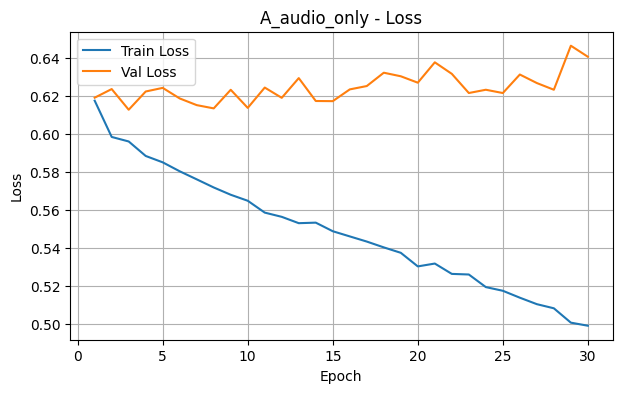

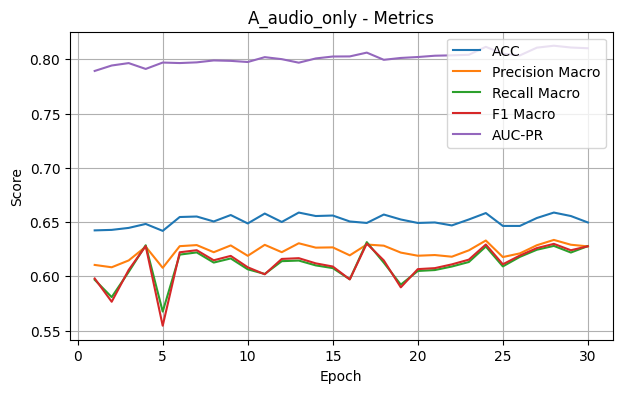

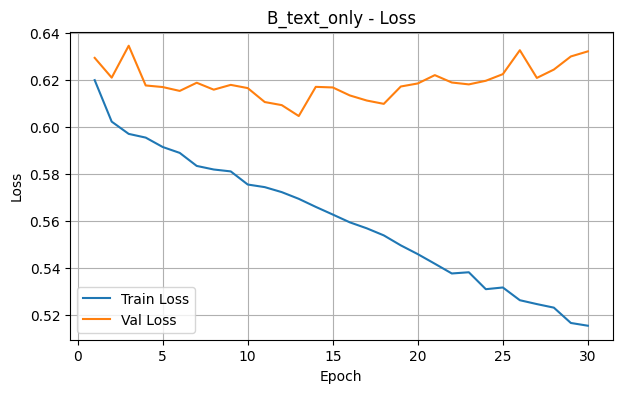

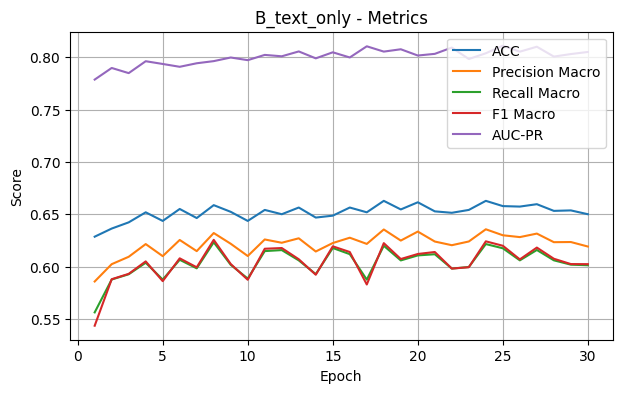

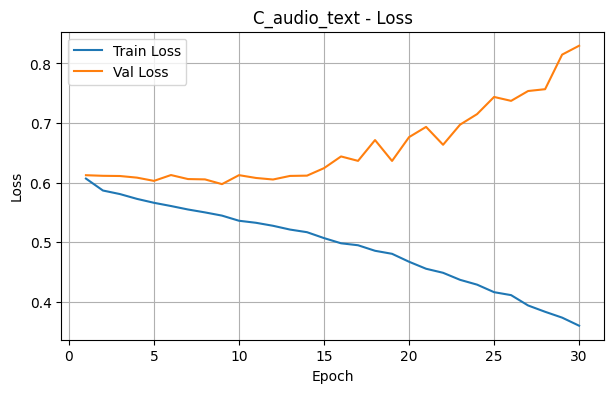

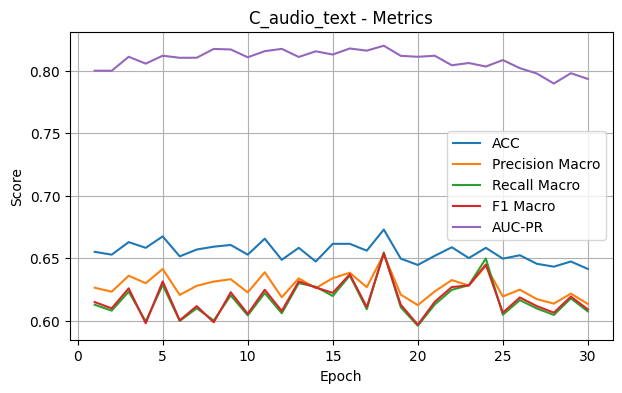

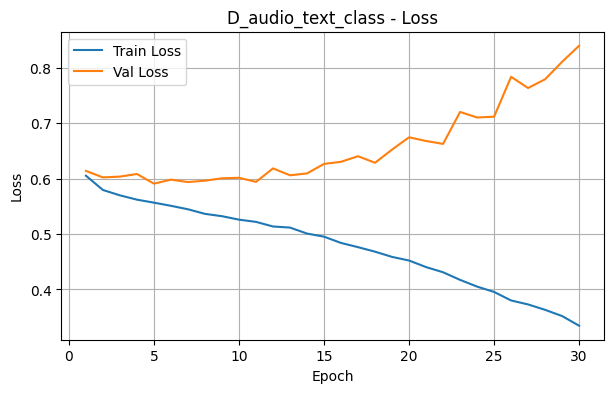

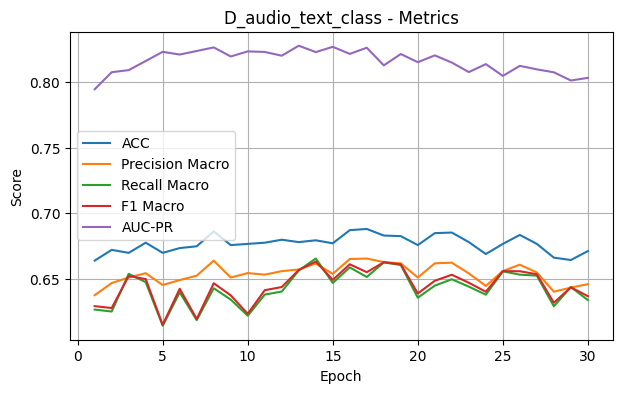

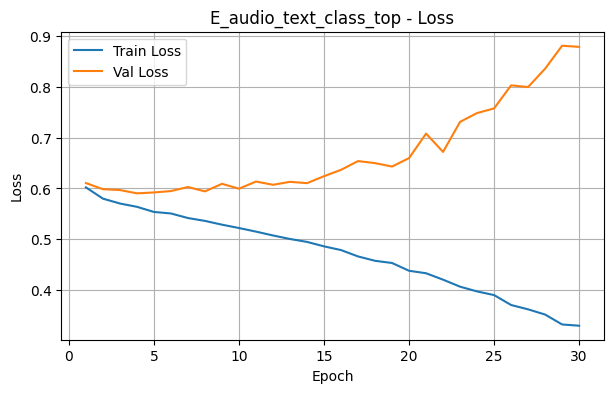

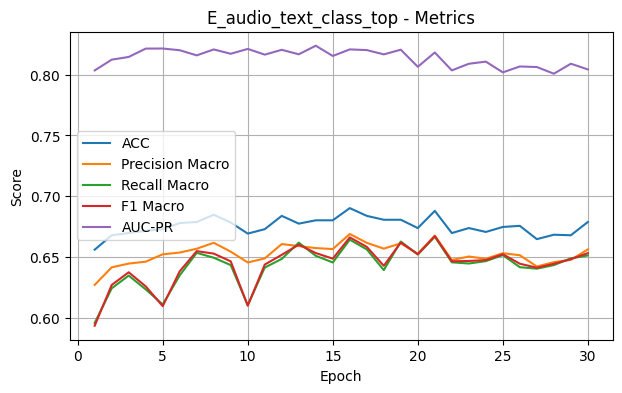

In [15]:

# =====================================================
# 15. TRAINING GRAPHS
# =====================================================

for exp_name, res in results.items():

    hist = res["history"]

    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist["train_loss"], label="Train Loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="Val Loss")
    plt.title(f"{exp_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist["acc"], label="ACC")
    plt.plot(hist["epoch"], hist["precision_macro"], label="Precision Macro")
    plt.plot(hist["epoch"], hist["recall_macro"], label="Recall Macro")
    plt.plot(hist["epoch"], hist["f1_macro"], label="F1 Macro")
    plt.plot(hist["epoch"], hist["auc_pr"], label="AUC-PR")
    plt.title(f"{exp_name} - Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()


Best experiment: E_audio_text_class_top

Classification Report

               precision    recall  f1-score   support

conf_123_to_0     0.5807    0.5386    0.5589       828
 conf_45_to_1     0.7317    0.7639    0.7475      1364

     accuracy                         0.6788      2192
    macro avg     0.6562    0.6513    0.6532      2192
 weighted avg     0.6747    0.6788    0.6763      2192

Confusion Matrix
[[ 446  382]
 [ 322 1042]]


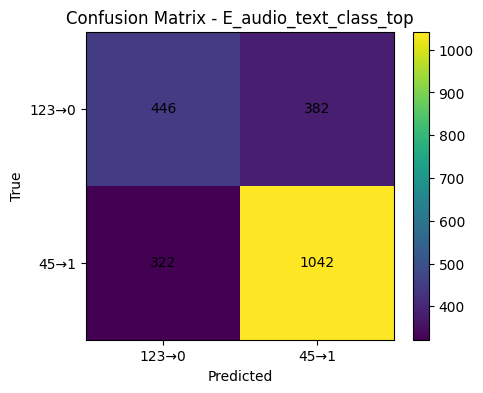

In [16]:

# =====================================================
# 16. BEST MODEL CONFUSION MATRIX / REPORT
# =====================================================

best_exp = summary_df.iloc[0]["experiment"]

print("Best experiment:", best_exp)

best = results[best_exp]

y_true = best["predictions"]["y_true"]
y_pred = best["predictions"]["y_pred"]
y_prob_1 = best["predictions"]["y_prob_1"]
val_indices = best["predictions"]["val_indices"]

print()
print("Classification Report")
print()

print(
    classification_report(
        y_true,
        y_pred,
        digits=4,
        target_names=[
            "conf_123_to_0",
            "conf_45_to_1"
        ]
    )
)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_exp}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["123→0", "45→1"])
plt.yticks([0, 1], ["123→0", "45→1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


Average Precision / AUC-PR: 0.8043699466890208
ROC-AUC: 0.7166045978721294


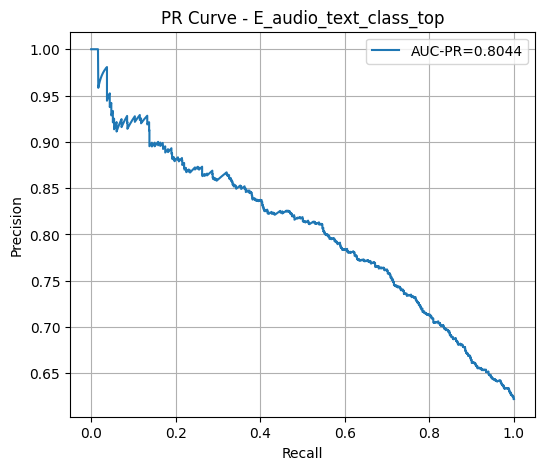

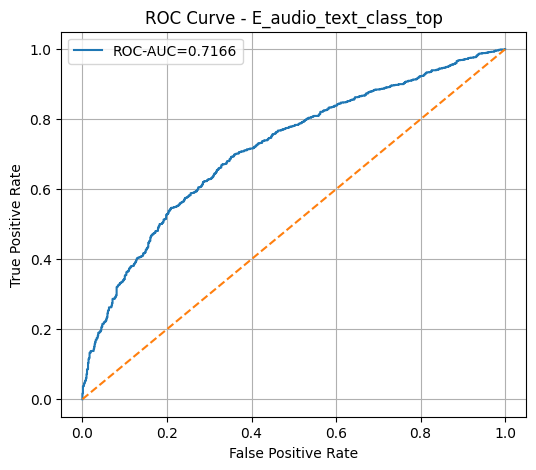

In [17]:

# =====================================================
# 17. PR CURVE / ROC CURVE
# =====================================================

ap = average_precision_score(y_true, y_prob_1)
auc = roc_auc_score(y_true, y_prob_1)

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob_1)
fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob_1)

print("Average Precision / AUC-PR:", ap)
print("ROC-AUC:", auc)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AUC-PR={ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve - {best_exp}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC={auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_exp}")
plt.legend()
plt.grid(True)
plt.show()


,threshold,accuracy,precision,recall,f1,retained_samples_pred_1,retained_ratio_pred_1
0,0.10,0.650091,0.652998,0.934018,0.768627,1951,0.890055
1,0.05,0.643248,0.644920,0.949413,0.768090,2008,0.916058
2,0.25,0.666058,0.678531,0.880499,0.766433,1770,0.807482
3,0.20,0.659215,0.668671,0.896628,0.766051,1829,0.834398
4,0.15,0.652372,0.660277,0.909091,0.764960,1878,0.856752
5,0.30,0.669252,0.687390,0.859238,0.763767,1705,0.777828
6,0.35,0.672901,0.697859,0.836510,0.760920,1635,0.745894
7,0.40,0.673358,0.707692,0.809384,0.755130,1560,0.711679
8,0.45,0.673358,0.716867,0.785191,0.749475,1494,0.681569
9,0.50,0.678832,0.731742,0.763930,0.747489,1424,0.649635


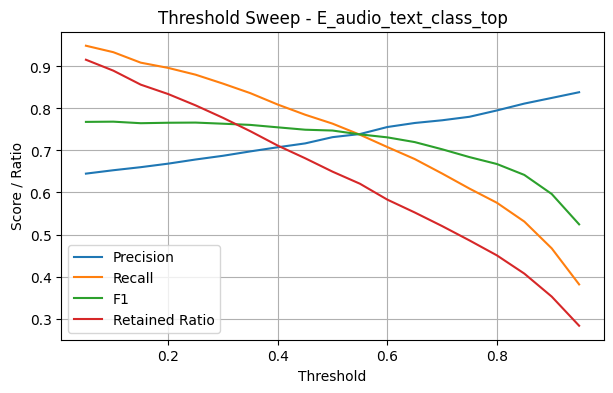

In [18]:

# =====================================================
# 18. THRESHOLD SWEEP ANALYSIS
# =====================================================

thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)

threshold_rows = []

for threshold in thresholds:

    pred_t = (y_prob_1 >= threshold).astype(int)

    retained = int(pred_t.sum())
    retained_ratio = retained / len(pred_t)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred_t),
        "precision": precision_score(y_true, pred_t, zero_division=0),
        "recall": recall_score(y_true, pred_t, zero_division=0),
        "f1": f1_score(y_true, pred_t, zero_division=0),
        "retained_samples_pred_1": retained,
        "retained_ratio_pred_1": retained_ratio,
    })

threshold_df = pd.DataFrame(threshold_rows)

display(threshold_df.sort_values("f1", ascending=False).reset_index(drop=True))

plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.plot(threshold_df["threshold"], threshold_df["retained_ratio_pred_1"], label="Retained Ratio")
plt.xlabel("Threshold")
plt.ylabel("Score / Ratio")
plt.title(f"Threshold Sweep - {best_exp}")
plt.legend()
plt.grid(True)
plt.show()


In [19]:

# =====================================================
# 19. PREDICTION DATAFRAME
# =====================================================

analysis_rows = []

for i, original_idx in enumerate(val_indices):

    r = rows[int(original_idx)]

    analysis_rows.append({
        "sound_id": r["sound_id"],
        "class_name": r["class_name"],
        "class_top_name": r["class_top_name"],
        "original_confidence": r["original_confidence"],
        "y_true": int(y_true[i]),
        "y_pred": int(y_pred[i]),
        "correct": bool(y_true[i] == y_pred[i]),
        "pred_prob_1_conf_45": float(y_prob_1[i]),
    })

pred_df = pd.DataFrame(analysis_rows)

display(pred_df.head(20))

print("Correct count:")
display(pred_df["correct"].value_counts())

print()
print("Predicted label distribution:")
display(pred_df["y_pred"].value_counts().sort_index())

print()
print("True label distribution:")
display(pred_df["y_true"].value_counts().sort_index())


,sound_id,class_name,class_top_name,original_confidence,y_true,y_pred,correct,pred_prob_1_conf_45
0,18557,m-m,m,3,0,0,True,0.259779
1,344076,fx-ex,fx,2,0,0,True,0.443285
2,40431,m-si,m,4,1,1,True,0.935023
3,64254,is-e,is,3,0,0,True,0.007505
4,18456,fx-n,fx,4,1,1,True,0.920679
5,245204,fx-o,fx,4,1,1,True,0.801186
6,147216,ss-s,ss,4,1,1,True,0.912090
7,270470,fx-h,fx,4,1,1,True,0.882033
8,28261,fx-v,fx,2,0,0,True,0.159394
9,355114,is-w,is,5,1,1,True,0.993645


Correct count:


,count
correct,
True,1488
False,704



Predicted label distribution:


,count
y_pred,
0,768
1,1424



True label distribution:


,count
y_true,
0,828
1,1364


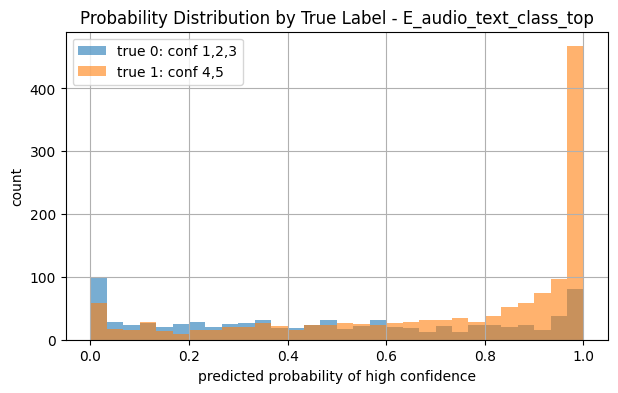

Probability summary by true label:


,count,mean,std,min,25%,50%,75%,max
y_true,,,,,,,,
0,828.0,0.4799,0.3347,0.0,0.1774,0.4662,0.7959,1.0
1,1364.0,0.7279,0.3133,0.0,0.5227,0.8764,0.9897,1.0



Probability summary by correctness:


,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
False,704.0,0.5380,0.3246,0.0,0.2700,0.5526,0.8366,1.0
True,1488.0,0.6798,0.3424,0.0,0.4002,0.8376,0.9860,1.0


In [20]:

# =====================================================
# 20. PROBABILITY DISTRIBUTION ANALYSIS
# =====================================================

plt.figure(figsize=(7, 4))
plt.hist(pred_df[pred_df["y_true"] == 0]["pred_prob_1_conf_45"], bins=30, alpha=0.6, label="true 0: conf 1,2,3")
plt.hist(pred_df[pred_df["y_true"] == 1]["pred_prob_1_conf_45"], bins=30, alpha=0.6, label="true 1: conf 4,5")
plt.xlabel("predicted probability of high confidence")
plt.ylabel("count")
plt.title(f"Probability Distribution by True Label - {best_exp}")
plt.legend()
plt.grid(True)
plt.show()

print("Probability summary by true label:")
display(
    pred_df.groupby("y_true")["pred_prob_1_conf_45"]
    .describe()
    .round(4)
)

print()
print("Probability summary by correctness:")
display(
    pred_df.groupby("correct")["pred_prob_1_conf_45"]
    .describe()
    .round(4)
)


Class-level performance:


,class_name,total,correct,mean_prob_1,true_high_ratio,pred_high_ratio,accuracy
6,fx-o,245,171,0.696946,0.677551,0.710204,0.697959
3,fx-h,180,121,0.657341,0.638889,0.700000,0.672222
18,sp-s,171,130,0.797055,0.754386,0.842105,0.760234
14,m-si,158,99,0.583240,0.537975,0.620253,0.626582
22,ss-u,141,89,0.300369,0.397163,0.241135,0.631206
15,m-sp,135,97,0.745283,0.666667,0.770370,0.718519
5,fx-n,127,79,0.719840,0.724409,0.740157,0.622047
10,is-p,125,94,0.767801,0.776000,0.752000,0.752000
12,is-w,109,90,0.721665,0.788991,0.779817,0.825688
9,is-k,97,82,0.682456,0.680412,0.649485,0.845361



Worst classes with at least 20 validation samples:


,class_name,total,correct,mean_prob_1,true_high_ratio,pred_high_ratio,accuracy
7,fx-v,35,17,0.592022,0.600000,0.657143,0.485714
4,fx-m,58,29,0.668027,0.517241,0.672414,0.500000
8,is-e,61,32,0.449491,0.426230,0.475410,0.524590
0,fx-a,34,18,0.563948,0.558824,0.617647,0.529412
20,ss-n,82,46,0.515048,0.585366,0.536585,0.560976
2,fx-ex,49,28,0.324274,0.306122,0.285714,0.571429
17,sp-p,65,38,0.425571,0.430769,0.415385,0.584615
1,fx-el,45,27,0.674308,0.600000,0.733333,0.600000
5,fx-n,127,79,0.719840,0.724409,0.740157,0.622047
19,ss-i,45,28,0.385503,0.400000,0.422222,0.622222


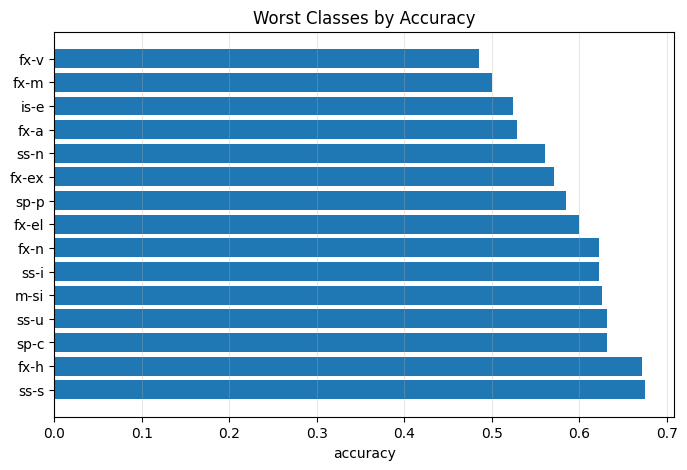

In [21]:

# =====================================================
# 21. ERROR ANALYSIS BY CLASS
# =====================================================

class_error = (
    pred_df
    .groupby("class_name")
    .agg(
        total=("correct", "size"),
        correct=("correct", "sum"),
        mean_prob_1=("pred_prob_1_conf_45", "mean"),
        true_high_ratio=("y_true", "mean"),
        pred_high_ratio=("y_pred", "mean"),
    )
    .reset_index()
)

class_error["accuracy"] = class_error["correct"] / class_error["total"]

class_error = class_error.sort_values(
    ["total", "accuracy"],
    ascending=[False, True]
)

print("Class-level performance:")
display(class_error.head(30))

print()
print("Worst classes with at least 20 validation samples:")
display(
    class_error[class_error["total"] >= 20]
    .sort_values("accuracy")
    .head(20)
)

top_error = class_error[class_error["total"] >= 20].sort_values("accuracy").head(15)

plt.figure(figsize=(8, 5))
plt.barh(top_error["class_name"], top_error["accuracy"])
plt.xlabel("accuracy")
plt.title("Worst Classes by Accuracy")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()


,original_confidence,total,correct,mean_prob_1,pred_high_ratio,accuracy
0,1,20,16,0.281800,0.200000,0.800000
1,2,139,90,0.389957,0.352518,0.647482
2,3,669,340,0.504529,0.491779,0.508221
3,4,1208,900,0.708698,0.745033,0.745033
4,5,156,142,0.876955,0.910256,0.910256


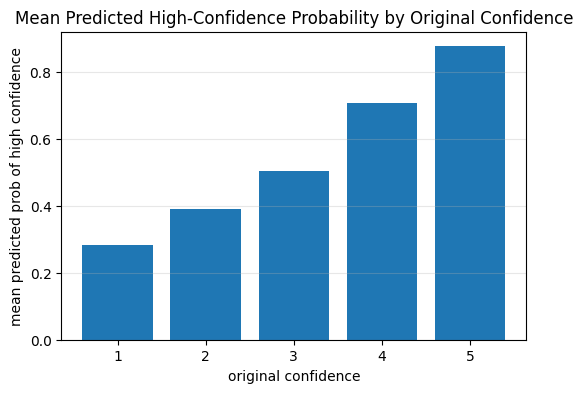

In [22]:

# =====================================================
# 22. ERROR ANALYSIS BY ORIGINAL CONFIDENCE
# =====================================================

conf_error = (
    pred_df
    .groupby("original_confidence")
    .agg(
        total=("correct", "size"),
        correct=("correct", "sum"),
        mean_prob_1=("pred_prob_1_conf_45", "mean"),
        pred_high_ratio=("y_pred", "mean"),
    )
    .reset_index()
)

conf_error["accuracy"] = conf_error["correct"] / conf_error["total"]

display(conf_error)

plt.figure(figsize=(6, 4))
plt.bar(conf_error["original_confidence"], conf_error["mean_prob_1"])
plt.xlabel("original confidence")
plt.ylabel("mean predicted prob of high confidence")
plt.title("Mean Predicted High-Confidence Probability by Original Confidence")
plt.grid(axis="y", alpha=0.3)
plt.show()


,top_ratio,selected_samples,precision_among_selected,threshold_min_score
0,0.1,219,0.894977,0.997987
1,0.2,438,0.865297,0.985453
2,0.3,657,0.837139,0.939767
3,0.4,876,0.812785,0.857537
4,0.5,1096,0.777372,0.727559
5,0.6,1315,0.745247,0.580531
6,0.7,1534,0.712516,0.426422
7,0.8,1753,0.680548,0.264368
8,0.9,1972,0.650101,0.080009


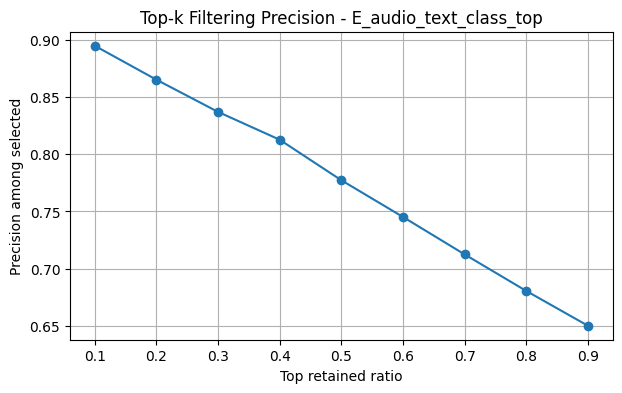

In [23]:

# =====================================================
# 23. TOP-K / RETAINED RATIO ANALYSIS
# =====================================================

# Filtering 관점:
# score가 높은 sample부터 상위 K%를 가져갔을 때 precision이 얼마나 되는지 본다.

sorted_pred = pred_df.sort_values("pred_prob_1_conf_45", ascending=False).reset_index(drop=True)

top_ratio_rows = []

for ratio in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:

    k = int(len(sorted_pred) * ratio)

    selected = sorted_pred.iloc[:k]

    precision_at_ratio = selected["y_true"].mean()

    top_ratio_rows.append({
        "top_ratio": ratio,
        "selected_samples": k,
        "precision_among_selected": precision_at_ratio,
        "threshold_min_score": selected["pred_prob_1_conf_45"].min(),
    })

top_ratio_df = pd.DataFrame(top_ratio_rows)

display(top_ratio_df)

plt.figure(figsize=(7, 4))
plt.plot(top_ratio_df["top_ratio"], top_ratio_df["precision_among_selected"], marker="o")
plt.xlabel("Top retained ratio")
plt.ylabel("Precision among selected")
plt.title(f"Top-k Filtering Precision - {best_exp}")
plt.grid(True)
plt.show()


In [24]:

# =====================================================
# 24. AUTOMATIC TEXT SUMMARY
# =====================================================

best_metrics = results[best_exp]["metrics"]

majority_acc = max(np.mean(y_true == 0), np.mean(y_true == 1))

summary_text = f'''
# Binary Confidence MLP Analysis Summary

Best experiment: {best_exp}

## Main metrics
- Accuracy: {best_metrics["acc"]:.4f}
- Macro Precision: {best_metrics["precision_macro"]:.4f}
- Macro Recall: {best_metrics["recall_macro"]:.4f}
- Macro F1: {best_metrics["f1_macro"]:.4f}
- Weighted F1: {best_metrics["f1_weighted"]:.4f}
- AUC-PR: {best_metrics["auc_pr"]:.4f}
- ROC-AUC: {best_metrics["auc_roc"]:.4f}

## Majority baseline
- Majority-class accuracy on validation: {majority_acc:.4f}

## Confusion matrix
{cm}

## Interpretation guide
- If high-confidence recall is high, the model catches many confidence 4~5 samples.
- If low-confidence recall is low, the model may incorrectly retain low/mid confidence samples.
- For filtering, threshold sweep and top-k precision are more important than only accuracy.
'''

print(summary_text)



# Binary Confidence MLP Analysis Summary

Best experiment: E_audio_text_class_top

## Main metrics
- Accuracy: 0.6788
- Macro Precision: 0.6562
- Macro Recall: 0.6513
- Macro F1: 0.6532
- Weighted F1: 0.6763
- AUC-PR: 0.8044
- ROC-AUC: 0.7166

## Majority baseline
- Majority-class accuracy on validation: 0.6223

## Confusion matrix
[[ 446  382]
 [ 322 1042]]

## Interpretation guide
- If high-confidence recall is high, the model catches many confidence 4~5 samples.
- If low-confidence recall is low, the model may incorrectly retain low/mid confidence samples.
- For filtering, threshold sweep and top-k precision are more important than only accuracy.



In [25]:

# =====================================================
# 25. SAVE RESULTS
# =====================================================

OUTPUT_DIR = "/content/binary_confidence_analysis_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

summary_path = os.path.join(OUTPUT_DIR, "summary_df.csv")
threshold_path = os.path.join(OUTPUT_DIR, "threshold_sweep.csv")
pred_path = os.path.join(OUTPUT_DIR, f"prediction_{best_exp}.csv")
class_error_path = os.path.join(OUTPUT_DIR, "class_error_analysis.csv")
top_ratio_path = os.path.join(OUTPUT_DIR, "top_ratio_filtering_analysis.csv")
class_map_path = os.path.join(OUTPUT_DIR, "class_to_idx.json")
summary_txt_path = os.path.join(OUTPUT_DIR, "analysis_summary.md")

summary_df.to_csv(summary_path, index=False)
threshold_df.to_csv(threshold_path, index=False)
pred_df.to_csv(pred_path, index=False)
class_error.to_csv(class_error_path, index=False)
top_ratio_df.to_csv(top_ratio_path, index=False)

with open(class_map_path, "w", encoding="utf-8") as f:
    json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

with open(summary_txt_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved summary:", summary_path)
print("Saved threshold sweep:", threshold_path)
print("Saved predictions:", pred_path)
print("Saved class error analysis:", class_error_path)
print("Saved top-ratio filtering analysis:", top_ratio_path)
print("Saved class mapping:", class_map_path)
print("Saved text summary:", summary_txt_path)


Saved summary: /content/binary_confidence_analysis_results/summary_df.csv
Saved threshold sweep: /content/binary_confidence_analysis_results/threshold_sweep.csv
Saved predictions: /content/binary_confidence_analysis_results/prediction_E_audio_text_class_top.csv
Saved class error analysis: /content/binary_confidence_analysis_results/class_error_analysis.csv
Saved top-ratio filtering analysis: /content/binary_confidence_analysis_results/top_ratio_filtering_analysis.csv
Saved class mapping: /content/binary_confidence_analysis_results/class_to_idx.json
Saved text summary: /content/binary_confidence_analysis_results/analysis_summary.md
